Train a small feed-forward neural network (PyTorch or TensorFlow) on a toy dataset. 


In [3]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#  Create toy dataset


X = np.array([
    [1, 50],
    [2, 55],
    [2, 60],
    [3, 65],
    [3, 70],
    [4, 75],
    [5, 80],
    [5, 85],
    [6, 90],
    [7, 95]
])

y = np.array([
    0, 0, 0, 0, 1,
    1, 1, 1, 1, 1
])

# Split data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Scale the input data

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Build Feed-Forward Neural Network

model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(2,)),

    tf.keras.layers.Dense(
        8,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        4,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

# Compile the model


model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train the model

history = model.fit(X_train, y_train , epochs = 100, verbose =1 )

#  Evaluate the model

loss, accuracy = model.evaluate(X_test, y_test, verbose=1)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

# Make predictions

probabilities = model.predict(X_test)

predictions = (probabilities >= 0.5).astype(int)

print("Actual:", y_test)
print("Predicted:", predictions.flatten())

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.8750 - loss: 0.5266
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.8750 - loss: 0.5232
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.8750 - loss: 0.5198
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8750 - loss: 0.5164
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.8750 - loss: 0.5131
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8750 - loss: 0.5098
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8750 - loss: 0.5066
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8750 - loss: 0.5034
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8750 - loss: 0.5002
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.8750 - loss: 0.4970
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8750 - loss: 0.4939
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8750 - loss

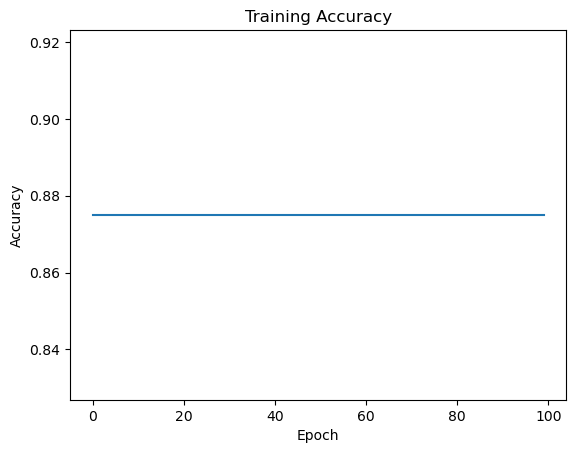

In [4]:
# visualize the dataset

import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"])

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")

plt.show()